In [1]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

import numpy as np

from matplotlib import pyplot as plt

In [2]:
Xraw = np.load("../../tmp/toy-experiments-dev/toy-dataset-eps0.1-seed1/x_train.npy")
yraw = np.load("../../tmp/toy-experiments-dev/toy-dataset-eps0.1-seed1/y_train.npy")

In [3]:
classes = [1, 4]
X = Xraw[np.isin(yraw, classes), :]
y = yraw[np.isin(yraw, classes)]
y = np.where(y == classes[0], 0, 1)


clf = QuadraticDiscriminantAnalysis()

clf.fit(X, y)

QuadraticDiscriminantAnalysis()

In [4]:
vmin = -1
vmax = 1

xv, yv = np.meshgrid(
    np.linspace(vmin, vmax, 100),
    np.linspace(vmin, vmax, 100),
)

grid = np.stack([xv.reshape(-1), yv.reshape(-1)]).T

In [5]:
clf.decision_function(grid).shape

(10000,)

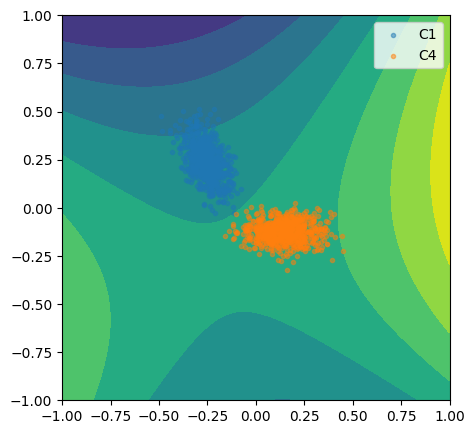

In [6]:
plt.figure(figsize=(5, 5))
plt.ylim([-1, 1]); plt.xlim([-1, 1]);
plt.contourf(xv, yv, clf.decision_function(grid).reshape(xv.shape))

for cix, c in enumerate(classes):
    plt.scatter(
        X[y==cix, 0],
        X[y==cix, 1],
        marker=".",
        alpha=0.5,
        label=f"C{c}"
    )
    
plt.legend()

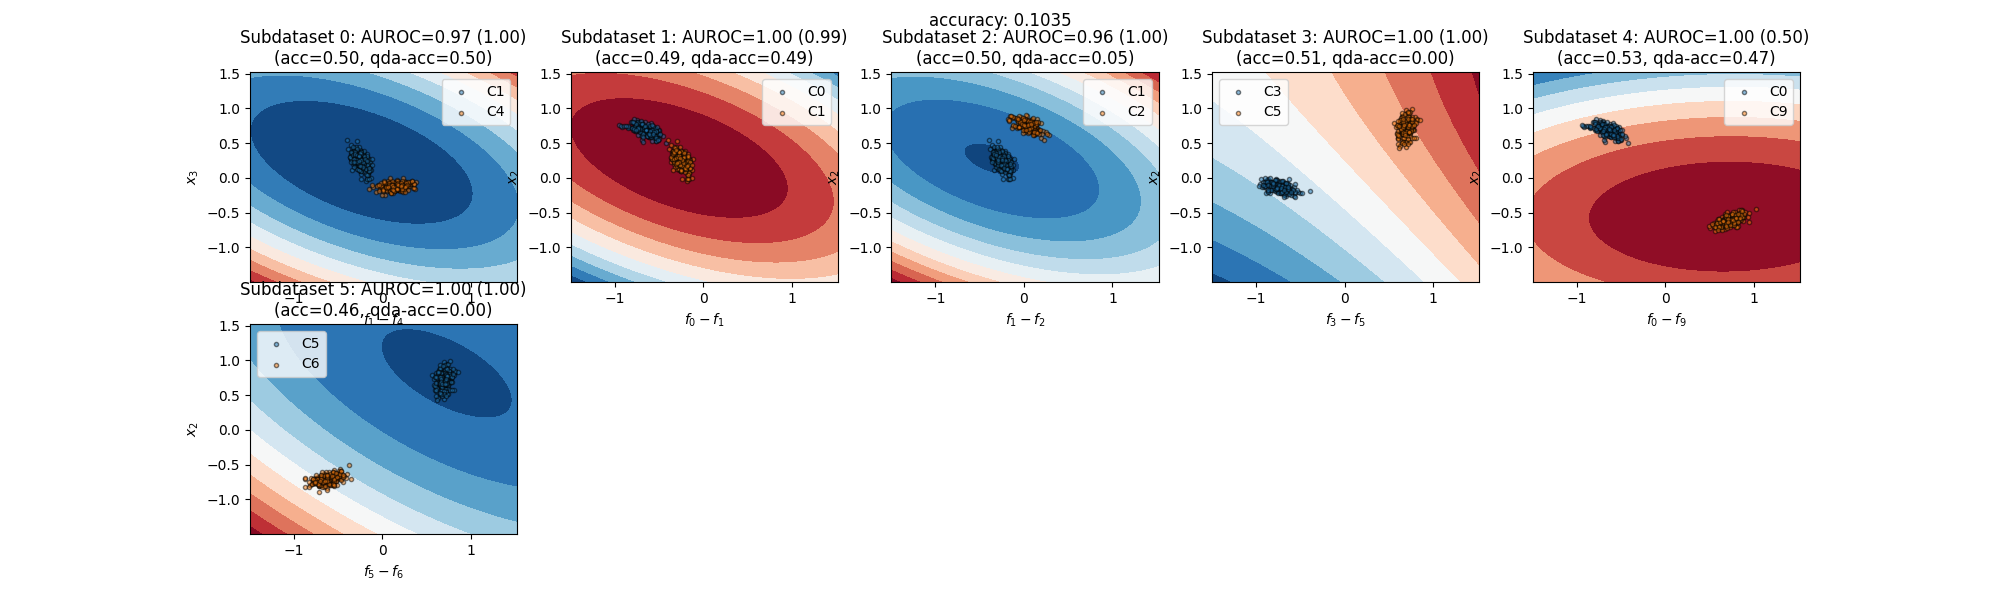